In [ ]:
                        #-------Filter_Based_Method---------#
# Filter based feature selection is a method that used statistical measure to score each feature independently and then select a feature based on these score.
# It is called 'filter' method because it filter out the feature that do not meet criteria.

In [ ]:
# Technique of filtering
    # Variance of threshold
    # Correlation
    # ANOVA
    # Chi squired
    # Mutual info

# Draw Back: It study only single feature and find relationship with single column.

In [ ]:
# Important Note:
# The first step of feature selection is to remove the duplicate column from the dataset.
# It is good strategy to split the train and test set before going for feature selection.


In [ ]:
# Plan of Example:
# First train and find the accuracy of LogisticRegression without feature selection.
# Then find the accuracy after feature selection.

In [1]:
# Example

# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
# Import Dataset
Data=pd.read_csv('Human_Activity.csv')
Data.shape

(7352, 563)

In [3]:
# Show the dataset
Data.head(2)

# Remove Categorical feature
Data=Data.drop(columns='subject')

In [4]:
# Shape of the data
Data.shape

(7352, 562)

In [4]:
# Check Target column
Data['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [5]:
# Extract Input Feature and Target Column
X=Data.drop(columns='Activity')
y=Data['Activity']

In [6]:
# Perform labelencoding on target column
encode=LabelEncoder()
y=encode.fit_transform(y)

In [7]:
# Split the dataset into train and testset
X_train, X_test, y_train, y_test=train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Show the shape of train and testset
print(X_train.shape)
print(X_test.shape)

(5881, 561)
(1471, 561)


In [9]:
# Applying LogisticRegression model

# Initialize and train logistic regression model
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# # Make predictions on the test set
y_pred=lr.predict(X_test)


In [10]:
# Find the accuracy
accuracy=accuracy_score(y_test, y_pred)
print("The accuracy of LogisticRegression:", accuracy)

The accuracy of LogisticRegression: 0.9809653297076818


In [ ]:
# Now perform feature selection
# First we have to find any duplicate columns

In [11]:
# First Check any duplicated columns present at dataset
def find_duplicate_columns(X_train):
    duplicates = {}
    
    for i in range(len(X_train.columns)):
        for j in range(i + 1, len(X_train.columns)):
            if X_train.iloc[:, i].equals(X_train.iloc[:, j]):
                col1 = X_train.columns[i]
                col2 = X_train.columns[j]
            
                if col1 in duplicates:
                    duplicates[col1].append(col2)
                else:
                    duplicates[col1] = [col2]
    
    return duplicates

In [12]:
# Find duplicate columns from X_train
duplicates = find_duplicate_columns(X_train)

In [13]:
# Show duplicates columns
duplicates

{'tBodyAccMag-mean()': ['tBodyAccMag-sma()',
  'tGravityAccMag-mean()',
  'tGravityAccMag-sma()'],
 'tBodyAccMag-std()': ['tGravityAccMag-std()'],
 'tBodyAccMag-mad()': ['tGravityAccMag-mad()'],
 'tBodyAccMag-max()': ['tGravityAccMag-max()'],
 'tBodyAccMag-min()': ['tGravityAccMag-min()'],
 'tBodyAccMag-sma()': ['tGravityAccMag-mean()', 'tGravityAccMag-sma()'],
 'tBodyAccMag-energy()': ['tGravityAccMag-energy()'],
 'tBodyAccMag-iqr()': ['tGravityAccMag-iqr()'],
 'tBodyAccMag-entropy()': ['tGravityAccMag-entropy()'],
 'tBodyAccMag-arCoeff()1': ['tGravityAccMag-arCoeff()1'],
 'tBodyAccMag-arCoeff()2': ['tGravityAccMag-arCoeff()2'],
 'tBodyAccMag-arCoeff()3': ['tGravityAccMag-arCoeff()3'],
 'tBodyAccMag-arCoeff()4': ['tGravityAccMag-arCoeff()4'],
 'tGravityAccMag-mean()': ['tGravityAccMag-sma()'],
 'tBodyAccJerkMag-mean()': ['tBodyAccJerkMag-sma()'],
 'tBodyGyroMag-mean()': ['tBodyGyroMag-sma()'],
 'tBodyGyroJerkMag-mean()': ['tBodyGyroJerkMag-sma()'],
 'fBodyAccMag-mean()': ['fBodyAccMag

In [14]:

# Get columns to remove
cols_to_remove = [col for sublist in duplicates.values() for col in sublist]

In [15]:
# Remove from train (NO inplace)
X_train = X_train.drop(columns=cols_to_remove)

In [16]:

# Align test
X_test = X_test[X_train.columns]

In [17]:
X_train.shape


(5881, 540)

In [18]:
# Show the shape of the new dataset

print(X_test.shape)


(1471, 540)


In [ ]:
# Variance of Threshold

# Variance of threshold will be applicable, if you have two types of feature:
    # 1. Constant feature: Var=0
    # 2. Quasi Constant : Var almost 0, Max row will be same

# Constant feature
# A     B       C
# 1     1       N
# 2     1       Y
# 3     1       Y

# Here, feature B is a constant feature as var=0 (All value same)
# So, Column B has no impact on target column, therefor we can drop it

# Suppose you have variance threshold 0.1 less than this value drop this column

In [19]:
# Import required libraries
from sklearn.feature_selection import VarianceThreshold

In [20]:
# Create variance threshold object
sel=VarianceThreshold(threshold=0.05)

In [21]:
# Tell sklearn to output pandas DataFrames
sel.set_output(transform="pandas")

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.05


In [22]:
# Fit the dataset
sel.fit(X_train)

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.05


In [23]:
# Show how many column pass threshold
sum(sel.get_support())

np.int64(349)

In [24]:
# Tell sklearn to output pandas DataFrames
sel.set_output(transform="pandas")

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.05


In [25]:
# Transform X_train and X_test
X_train=sel.transform(X_train)
X_test=sel.transform(X_test)

In [26]:
# Type of X_train
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [27]:
# Show the total column after performing variance threshold
print(X_train.shape)
print(X_test.shape)

(5881, 349)
(1471, 349)


In [ ]:
# Points to consider during variance 
# Ignore Target Variable: 
    # Variance Threshold is a univariate method, it does not consider relationship between each feature and the target variable.
    # This may keep irrelevent feature have a high variance but no relationship with target.
    # Discard feature that have low variance but storg relationship with target.
# Sensitive to Scaling:
    # Variance Threshold is sensitive to the scale of the data.
    # If features are not on the same scale the variance will naturally be higher for features with larger values
# Arbitary Threshold Value: 
    # Optimal value can vary between datasets.

In [ ]:
# Correlation is a statistical measure that shows the strength and direction of relationship between two variables.

# In feature selection, correlation is used to:
    # Identify features that are strongly related to the target variable
    # Remove features that are highly correlated with each other (to avoid redundancy)

In [ ]:
# keep features with high absolute correlation with the target.
# Correlation coefficient (Pearson’s r):
    # +1 → Perfect positive correlation
    # -1 → Perfect negative correlation
    # 0 → No correlation

In [ ]:
# Correlation Between Features (Multicollinearity)
    # If two input features are highly correlated
    # Remove one of the highly correlated features.

In [ ]:
# Disadvantages:
# Linearity Assumtion:
    # Corelation measures the linear relationship between two variables. It does not capture non-linear relationship.
    # Does not capture Complex relationship
    # Threshold determination
    # Sensitive to outlier

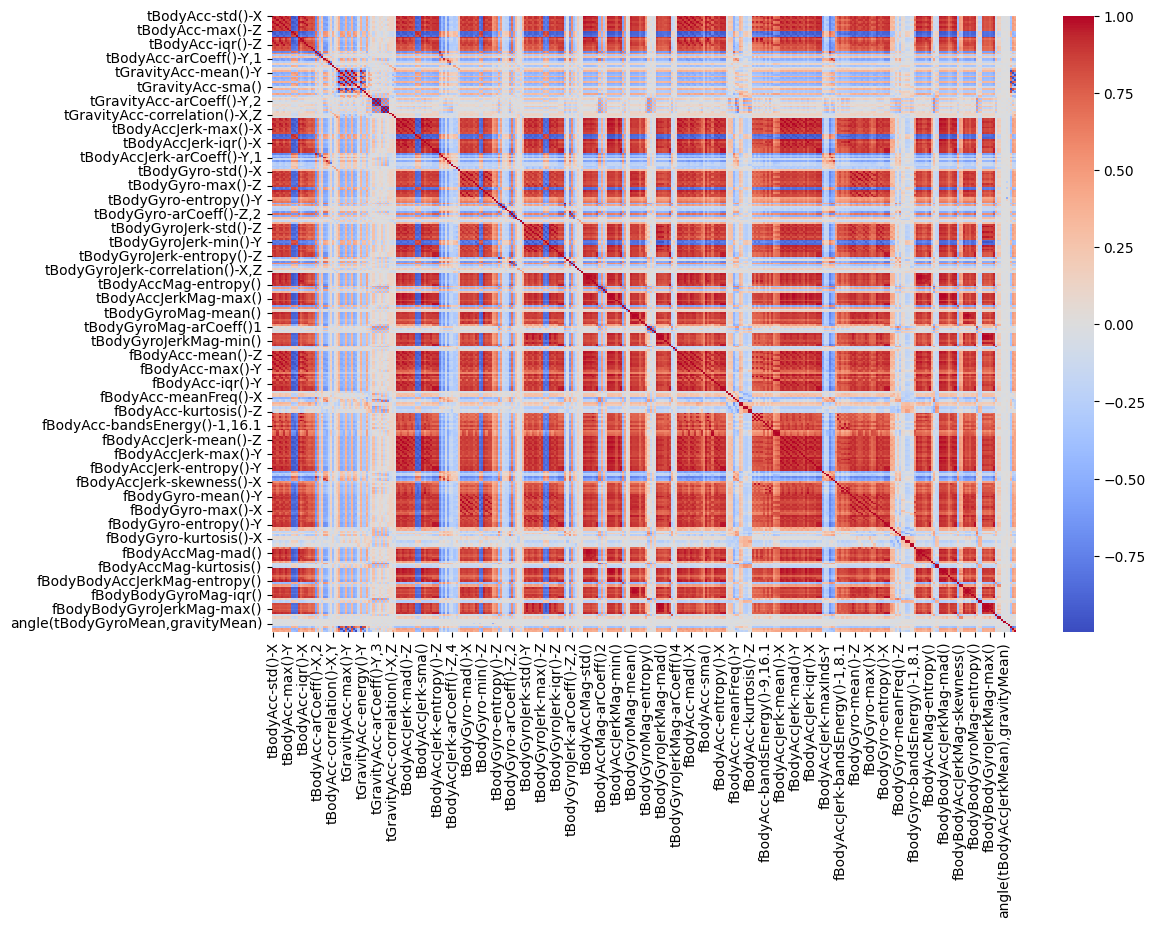

In [28]:
# Visualize correlation matrix 
plt.figure(figsize=(12,8)) 
sns.heatmap(X_train.corr(), cmap="coolwarm", annot=False)
plt.show()

In [29]:
# Compute correlation matrix 
corr_matrix = X_train.corr().abs()

In [30]:
# Get the column names of the DataFrame
columns = corr_matrix.columns

# Create an empty list to keep track of columns to drop
columns_to_drop = []

# Loop over the columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        # Access the cell of the DataFrame
        if corr_matrix.loc[columns[i], columns[j]] > 0.95:
            columns_to_drop.append(columns[j])

print(len(columns_to_drop))

1591


In [31]:
# Remove duplicate value
columns_to_drop = set(columns_to_drop)

In [32]:
len(columns_to_drop)

212

In [33]:
# Remove column
X_train=X_train.drop(columns = columns_to_drop)
X_test=X_test.drop(columns = columns_to_drop)

In [34]:
# Show the shape
print(X_train.shape)
print(X_test.shape)

(5881, 137)
(1471, 137)


In [ ]:
                    # ----------ANOVA----------#
# ANOVA is a statistical test used to check whether the means of two or more groups are significantly different.

In [ ]:
# Basic Idea of ANOVA
# ANOVA compares:
    # Between-group variance (difference between class means)
    # Within-group variance (variation inside each class)
    # It calculates something called the F-statistic:
    # F=Between-group variance​/Within-group variance

# Large F value → Feature differs significantly between classes → Good feature
# Small F value → Feature does not differ much → Not useful

# We use ANOVA when the target variable is categorical and the features are numerical.
# ANOVA F-test is commonly used for feature selection in classification problems.

In [ ]:
# ANOVA compares between variance vs within variance.
# F= MSB​/ MSW
# MSW= Mean Square Within Groups
# MSB= Mean Square Between Groups

# MSB is the average between-group variance.
# MSB=SSB/ k−1, k = number of groups

# MSW is the average within-group variance.
# MSW=SSW​/N−k
# N = total samples
# k = number of groups


# SSB — Sum of Squares Between Groups
# It measures the variation between different classes.
# SSB=∑ni​(Xi​ˉ​−Xˉ)2
# ni= number of samples in group i
# Xi= mean of group i
# X=overall mean

# SSW — Sum of Squares Within Groups
# It measures how spread out the data points are within the same class.
# SSW=∑(Xij​−Xi​ˉ​)2
# Xij= individual value
# Xi= group mean

In [35]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest


sel = SelectKBest(f_classif, k=100).fit(X_train, y_train)

# display selected feature names
X_train.columns[sel.get_support()]

Index(['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-max()-Z', 'tBodyAcc-min()-Z', 'tBodyAcc-entropy()-X',
       'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z',
       'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2',
       'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4',
       'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Z,1',
       'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-Y,Z',
       'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z',
       'tGravityAcc-sma()', 'tGravityAcc-energy()-Y', 'tGravityAcc-energy()-Z',
       'tGravityAcc-entropy()-X', 'tGravityAcc-entropy()-Y',
       'tGravityAcc-arCoeff()-Y,1', 'tGravityAcc-arCoeff()-Z,1',
       'tGravityAcc-correlation()-X,Y', 'tGravityAcc-correlation()-Y,Z',
       'tBodyAccJerk-std()-Z', 'tBodyAccJerk-entropy()-X',
       'tBodyAccJerk-arCoeff()-X,3', 'tBodyAccJerk-arCoeff()-Z,3',
       'tBodyAccJerk-arCoeff()-Z,4', 'tBodyAccJerk-correlation()-X,Y',
       '

In [36]:
# Store Column Names
columns = X_train.columns[sel.get_support()]

In [37]:
# Fit and transform
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

X_train = pd.DataFrame(X_train, columns=columns)
X_test = pd.DataFrame(X_test, columns=columns)

In [38]:
print(X_train.shape)
print(X_test.shape)

(5881, 100)
(1471, 100)


In [ ]:
# Again Perform logistic regression

# Initialize and train logistic regression model
log_reg = LogisticRegression(max_iter=1000)  # Increase max_iter if it doesn't converge
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 0.9700883752549286


In [ ]:
# The Chi-square (χ²) test is a statistical test used to determine whether there is a significant relationship between two categorical variables.
# It measures the difference between observed frequencies and expected frequencies.

# Conditions for Using Chi-square

    # Chi-square feature selection works when:
    # Features are categorical
    # Target variable is categorical
    # Data are frequency/count data

In [43]:
# Code Example
# Import Data
titanic = pd.read_csv('titanic.csv', usecols=['Pclass','Sex','SibSp','Parch','Embarked','Survived'])
titanic.head()

,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0,3,male,1,0,S
1,1,1,female,1,0,C
2,1,3,female,0,0,S
3,1,1,female,1,0,S
4,0,3,male,0,0,S


In [44]:
# Import libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt

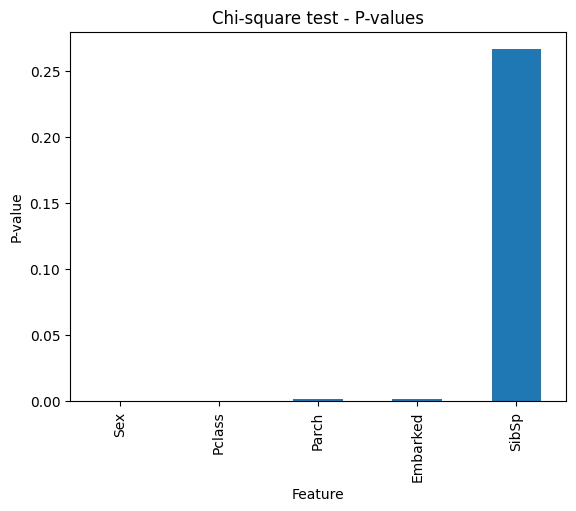

In [ ]:

# assuming titanic is your DataFrame and 'Survived' is the target column

# Encode categorical variables
le = LabelEncoder()
titanic_encoded = titanic.apply(le.fit_transform)

X = titanic_encoded.drop('Survived', axis=1)
y = titanic_encoded['Survived']

# Calculate chi-squared stats
chi_scores = chi2(X, y)

# chi_scores[1] are the p-values of each feature.
p_values = pd.Series(chi_scores[1], index = X.columns)
p_values.sort_values(inplace = True)

# Plotting the p-values
p_values.plot.bar()

plt.title('Chi-square test - P-values')
plt.xlabel('Feature')
plt.ylabel('P-value')
plt.show()